## **Limpieza y Transformación de Datos**


* Se abordará el proceso de limpieza y preparación de los datos, con énfasis en la eliminación de valores que carecen de explicación lógica y en la transformación de variables.

* En esta etapa se identificarán y tratarán registros inconsistentes, valores atípicos no justificados y errores derivados de la captura o integración de los datos. Asimismo, se aplicarán transformaciones sobre las variables con el objetivo de mejorar su distribución, reducir sesgos y optimizar el desempeño de los modelos predictivos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/car_sales_data.csv')

In [ ]:
df.head()

,Fabricante,Modelo,Motor,Combustible,Año,Kilometraje,Precio
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


## **Eliminación de valores atípicos**

In [ ]:
df.query("Año < 1997 and Combustible == 'Hybrid'") \
.Modelo.unique()  °

array(['RAV4', 'Golf', 'Prius', 'Yaris', 'Fiesta', 'Focus', 'Mondeo'],
      dtype=object)

In [ ]:
df["is_outlier"] = (

    (df.Año <= 2001) &
    (df.Combustible == 'Hybrid') &
    (df.Modelo != 'Prius')

)

In [ ]:
df = df.query("is_outlier == False")
df = df.query("is_outlier == False")

* Durante la exploración de los datos se identificaron vehículos con año de fabricación anterior a 2001 que aparecen clasificados como híbridos. Sin embargo, modelos como **RAV4, Golf, Prius, Yaris, Fiesta, Focus** y **Mondeo** no contaban con versiones híbridas comercializadas antes de ese periodo. Este comportamiento no responde a una lógica de negocio ni al contexto histórico del mercado automotriz, por lo que se concluye que estos registros corresponden a errores de captura o inconsistencias en la base de datos.

## **¿La transformación logarítmica del precio mejora la relación lineal con el kilometraje y reduce la heterocedasticidad del modelo?**

In [ ]:
sns.set_style('whitegrid')

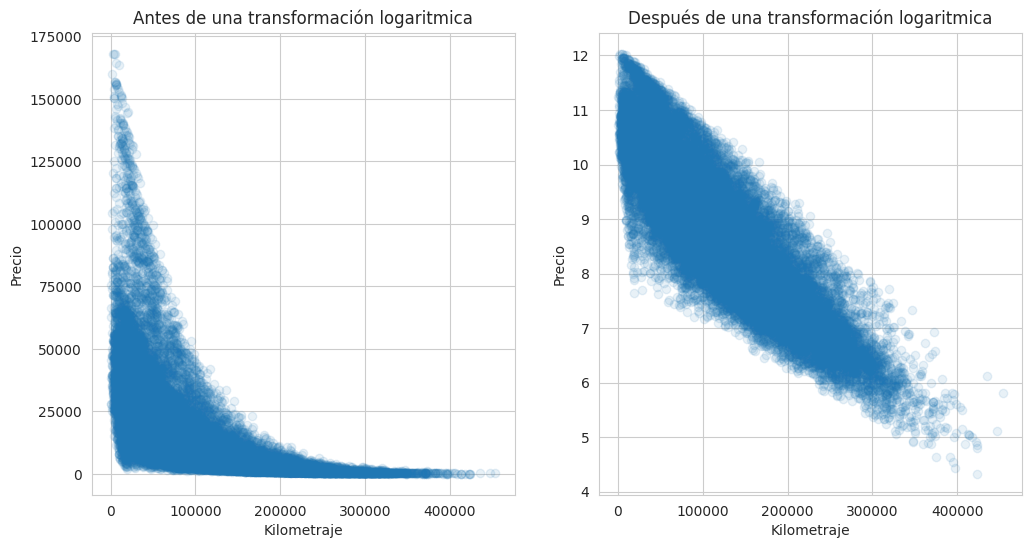

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,6))



ax1.set_title('Antes de una transformación logaritmica')
ax1.scatter(df.Kilometraje,df.Precio,alpha = 0.1)
ax1.set_xlabel('Kilometraje')
ax1.set_ylabel('Precio')


ax2.set_title('Después de una transformación logaritmica')
ax2.scatter(df.Kilometraje,np.log(df.Precio),alpha = 0.1)
ax2.set_xlabel('Kilometraje')
ax2.set_ylabel('Precio')


plt.show()



* Al aplicar una transformación logarítmica a la variable objetivo **Precio**, se observa una relación más cercana a la linealidad con la variable Kilometraje. Esta transformación permite **reducir la heterocedasticidad** presente en los datos originales, haciendo que la varianza del precio sea más homogénea a lo largo del rango de kilometraje.

* La **transformación logarítmica** comprime la escala de los valores, **reduciendo la influencia de precios extremadamente altos y ampliando la representación de valores bajos y medios.** De esta forma, se atenúa el impacto de los valores máximos y mínimos sin eliminar observaciones relevantes desde la perspectiva del negocio.

## **Conclusión**

* Asimismo, se evidenció la importancia de aplicar transformaciones adecuadas sobre las variables numéricas. La transformación logarítmica de la variable Precio permitió reducir la heterocedasticidad del modelo, atenuando la influencia de valores extremos y comprimiendo los rangos mínimos y máximos. Esto facilita una relación más estable entre el precio y variables explicativas como el kilometraje.


* El resto de las variables numéricas, como el año de fabricación y la cilindrada del motor, pueden ser procesadas mediante técnicas de escalado estándar (StandardScaler), mientras que las variables categóricas serán codificadas utilizando OneHotEncoding. No obstante, estas transformaciones no se aplicaron de manera manual en esta etapa, con el objetivo de integrarlas posteriormente mediante ColumnTransformer y combinarlas junto con el modelo dentro de un Pipeline. Este enfoque permite una mayor trazabilidad, evita fugas de información y facilita la reproducibilidad y el despliegue del modelo en un entorno de producción.

In [ ]:
df.to_csv('/content/drive/MyDrive/dataset/car_sales_data_clean.csv',index = False)